In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/thermalplant221/hispa/hispa/thermalimage29d.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage33a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage4a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage14c.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage64a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage2a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage66a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage52a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage11b.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage42a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage57a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage21a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage31a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage27a.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage.jpg
/kaggle/input/thermalplant221/hispa/hispa/thermalimage63b.jpg
/kaggle/input

In [2]:
pip install torch torchvision pillow numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.4 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Epoch 1/120:
Training Loss: 1.7625, Training Accuracy: 16.01%
Validation Loss: 1.8158, Validation Accuracy: 3.94%
Epoch 2/120:
Training Loss: 1.6296, Training Accuracy: 27.03%
Validation Loss: 1.8052, Validation Accuracy: 23.62%
Epoch 3/120:
Training Loss: 1.6444, Training Accuracy: 24.67%
Validation Loss: 2.2081, Validation Accuracy: 5.51%
Epoch 4/120:
Training Loss: 1.5751, Training Accuracy: 27.82%
Validation Loss: 1.6183, Validation Accuracy: 20.47%
Epoch 5/120:
Training Loss: 1.5866, Training Accuracy: 27.30%
Validation Loss: 1.5331, Validation Accuracy: 40.16%
Epoch 6/120:
Training Loss: 1.5167, Training Accuracy: 31.50%
Validation Loss: 1.5707, Validation Accuracy: 38.58%
Epoch 7/120:
Training Loss: 1.4965, Training Accuracy: 27.03%
Validation Loss: 1.5333, Validation Accuracy: 48.82%
Epoch 8/120:
Training Loss: 1.4686, Training Accuracy: 33.33%
Validation Loss: 1.5526, Validation Accuracy: 44.09%
Epoch 9/120:
Training Loss: 1.4181, Training Accuracy: 25.72%
Validation Loss: 1.4

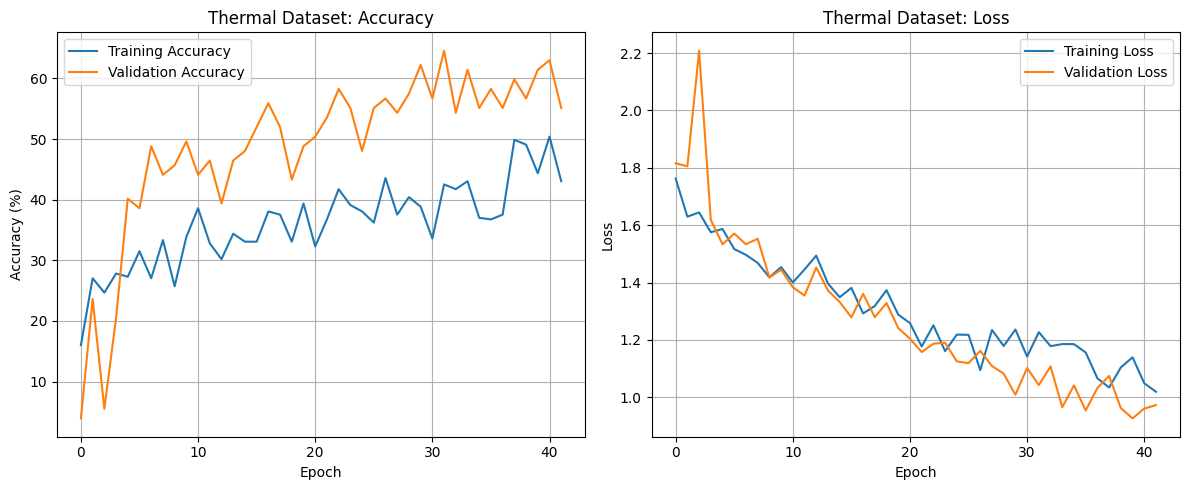

Class to Index Mapping:
BLB: 0
Blast: 1
healthy: 2
hispa: 3
leaf folder: 4
leaf spot: 5


In [3]:


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from sklearn.metrics import precision_recall_curve, average_precision_score

class YOLOv11Classifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super(YOLOv11Classifier, self).__init__()
        
        # Base feature extractor
        self.features = nn.Sequential(
            # Initial convolution block
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Second convolution block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Third convolution block with attention
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Fourth convolution block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Fifth convolution block
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # Added Conv Block
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),  # Added Dropout
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class ThermalPlantDiseaseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['BLB', 'Blast', 'healthy', 'hispa', 'leaf folder', 'leaf spot']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.images = []
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):  # Check if it's a directory
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):  # Check for image files
                        self.images.append((os.path.join(class_path, img_name), self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        # Load as grayscale and convert to 3 channels for model compatibility
        image = Image.open(img_path).convert('L')
        image = np.array(image)
        image = np.stack([image] * 3, axis=-1)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        image = torch.FloatTensor(image.transpose(2, 0, 1)) / 255.0
        return image, label

def get_thermal_augmentations():
    return A.Compose([
        A.Resize(224, 224),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0)),
            A.GaussianBlur(blur_limit=(3, 7)),
            A.MotionBlur(blur_limit=(3, 7)),  # Added Motion Blur
        ], p=0.5),
        A.HorizontalFlip(p=0.5),      # Added Horizontal Flip
        A.VerticalFlip(p=0.5),        # Added Vertical Flip
        A.RandomRotate90(p=0.5),      # Added Random Rotation
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),  # Added Color Jitter
        A.Normalize(
            mean=[0.485, 0.485, 0.485],  # Same value for all channels since it's thermal
            std=[0.229, 0.229, 0.229]
        ),
    ])

def mixup_data(x, y, alpha=0.2):
    """Applies MixUp augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculates MixUp loss."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=10, mixup_alpha=0.2):
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []
    best_val_accuracy = 0.0
    best_model_state = None  # Store the state of the best model
    epochs_no_improve = 0    # Counter for early stopping
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_train_correct = 0
        running_train_total = 0
        running_train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Apply MixUp
            inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, mixup_alpha)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            running_train_total += labels.size(0)
            running_train_correct += (predicted == labels).sum().item()
        
        train_accuracy = 100 * running_train_correct / running_train_total
        train_loss = running_train_loss / running_train_total
        train_accuracies.append(train_accuracy)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        running_val_correct = 0
        running_val_total = 0
        running_val_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                running_val_total += labels.size(0)
                running_val_correct += (predicted == labels).sum().item()
        
        val_accuracy = 100 * running_val_correct / running_val_total
        val_loss = running_val_loss / running_val_total
        val_accuracies.append(val_accuracy)
        val_losses.append(val_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        
        # Early Stopping Check
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = model.state_dict()  # Save the model state
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print("Early stopping triggered!")
                model.load_state_dict(best_model_state)  # Restore best model
                break  # Stop the training loop
    
    return train_accuracies, val_accuracies, train_losses, val_losses

def calculate_class_weights(dataset):
    class_counts = torch.zeros(len(dataset.classes))
    for _, label in dataset:
        class_counts[label] += 1
    return len(dataset) / (len(dataset.classes) * class_counts)

def main_thermal():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Thermal-specific augmentations
    thermal_transform = get_thermal_augmentations()
    
    # Load thermal dataset
    dataset = ThermalPlantDiseaseDataset(
        root_dir='/kaggle/input/d/sujaradha/thermal-images-diseased-healthy-leaves-paddy/thermal images UL',
        transform=thermal_transform
    )
    
    # Calculate class weights for imbalanced dataset
    class_weights = calculate_class_weights(dataset)
    
    # Split dataset (60-20-20)
    total_size = len(dataset)
    train_size = int(0.6 * total_size)
    val_size = int(0.2 * total_size)
    test_size = total_size - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size]
    )
    
    # Create data loaders
    batch_size = 16  # Smaller batch size for thermal
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Initialize model
    model = YOLOv11Classifier(num_classes=len(dataset.classes)).to(device)
    
    # Training parameters
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    learning_rate = 0.0001  # Reduced learning rate
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)  # Added L2 Regularization
    num_epochs = 120
    
    # Train and evaluate
    train_accuracies, val_accuracies, train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs, device
    )
    
    # Plot training curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Thermal Dataset: Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Thermal Dataset: Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print the class mapping
    print("Class to Index Mapping:")
    for class_name, idx in dataset.class_to_idx.items():
        print(f"{class_name}: {idx}")

if __name__ == '__main__':
    main_thermal()